# Exploratory Data Analysis — News Category Dataset
**Projet** : AI NewsOps Platform — MLOps Pipeline AIA Bloc 4
**Auteur** : Frédéric Dreipfelt
**Date** : 2026

## Objectifs de cet EDA
1. Comprendre la structure brute du dataset
2. Analyser la distribution des classes et détecter le déséquilibre
3. Explorer les caractéristiques textuelles (longueur, vocabulaire, densité)
4. Détecter les anomalies : doublons, valeurs manquantes, dérives temporelles
5. Justifier les décisions de preprocessing (fusion catégories, seuils)
6. Produire des visualisations publiables pour le rapport de certification

## 0. Setup et chargement

In [1]:
import sys
print(sys.executable)

/home/frederic/Documents/Jedha/Jedha/03_Data Science  and  Eng - Lead/10_Projects/ai-newsops-platform/.venv/bin/python


In [2]:
import os
import re
import json
import warnings
from pathlib import Path
from collections import Counter
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from scipy.stats import chi2_contingency
import kagglehub

warnings.filterwarnings("ignore")

# ── Style global ──────────────────────────────────────────────────────────────
PALETTE_PRIMARY   = "#5B4FCF"   # purple — couleur projet
PALETTE_SECONDARY = "#1D9E75"   # teal
PALETTE_DANGER    = "#D85A30"   # coral
PALETTE_NEUTRAL   = "#888780"   # gray
CMAP_DIV          = "RdYlGn"
CMAP_SEQ          = "viridis"

plt.rcParams.update({
    "figure.facecolor":  "white",
    "axes.facecolor":    "#FAFAFA",
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "axes.labelsize":    12,
    "axes.titlesize":    14,
    "axes.titleweight":  "bold",
    "xtick.labelsize":   10,
    "ytick.labelsize":   10,
    "legend.fontsize":   10,
    "font.family":       "DejaVu Sans",
})

OUTPUT_DIR = Path("reports/figures")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

def savefig(name: str):
    plt.savefig(OUTPUT_DIR / f"{name}.png", dpi=150, bbox_inches="tight")
    plt.show()
    print(f"  → Sauvegardé : reports/figures/{name}.png")

# ── Chargement via kagglehub ───────────────────────────────────────────────────
print("Téléchargement du dataset depuis Kaggle...")
path = kagglehub.dataset_download("rmisra/news-category-dataset")
JSON_PATH = os.path.join(path, "News_Category_Dataset_v3.json")

df_raw = pd.read_json(JSON_PATH, lines=True)
df_raw["date"] = pd.to_datetime(df_raw["date"], errors="coerce")

print(f"\nDataset chargé : {df_raw.shape[0]:,} lignes × {df_raw.shape[1]} colonnes")

Téléchargement du dataset depuis Kaggle...

Dataset chargé : 209,527 lignes × 6 colonnes


## 1. Vue d'ensemble structurelle

In [3]:
print("=" * 60)
print("RAPPORT STRUCTUREL — News Category Dataset v3")
print("=" * 60)

print(f"\n{'Dimensions':<30} {df_raw.shape[0]:>10,} lignes × {df_raw.shape[1]} colonnes")
print(f"{'Colonnes':<30} {list(df_raw.columns)}")
print(f"{'Mémoire (MB)':<30} {df_raw.memory_usage(deep=True).sum() / 1e6:>10.1f}")
print(f"{'Période':<30} {df_raw['date'].min().date()} → {df_raw['date'].max().date()}")
print(f"{'Catégories distinctes':<30} {df_raw['category'].nunique():>10}")
print(f"{'Auteurs distincts':<30} {df_raw['authors'].nunique():>10,}")

print("\n── Valeurs manquantes ──────────────────────────────")
missing = df_raw.isnull().sum()
missing_pct = (missing / len(df_raw) * 100).round(2)
missing_df = pd.DataFrame({"count": missing, "pct_%": missing_pct})
print(missing_df[missing_df["count"] > 0].to_string() or "  Aucune valeur manquante NaN")

# Compter les chaînes vides (qui ne sont pas NaN)
print("\n── Chaines vides (non-NaN) ─────────────────────────")
for col in ["headline", "short_description", "authors"]:
    n_empty = (df_raw[col].astype(str).str.strip() == "").sum()
    print(f"  {col:<25} {n_empty:>6,}  ({n_empty/len(df_raw)*100:.2f}%)")

print("\n── Types de colonnes ────────────────────────────────")
print(df_raw.dtypes.to_string())

RAPPORT STRUCTUREL — News Category Dataset v3

Dimensions                        209,527 lignes × 6 colonnes
Colonnes                       ['link', 'headline', 'category', 'short_description', 'authors', 'date']
Mémoire (MB)                        129.1
Période                        2012-01-28 → 2022-09-23
Catégories distinctes                  42
Auteurs distincts                  29,169

── Valeurs manquantes ──────────────────────────────
Empty DataFrame
Columns: [count, pct_%]
Index: []

── Chaines vides (non-NaN) ─────────────────────────
  headline                       6  (0.00%)
  short_description         19,712  (9.41%)
  authors                   37,418  (17.86%)

── Types de colonnes ────────────────────────────────
link                         object
headline                     object
category                     object
short_description            object
authors                      object
date                 datetime64[ns]


## 2. Analyse des doublons

In [4]:
print("\n── Analyse des doublons ─────────────────────────────")

dup_full    = df_raw.duplicated().sum()
dup_link    = df_raw.duplicated(subset=["link"]).sum()
dup_hl      = df_raw.duplicated(subset=["headline"]).sum()
dup_hl_desc = df_raw.duplicated(subset=["headline", "short_description"]).sum()

print(f"  Doublons (toutes colonnes)      : {dup_full:>5,}")
print(f"  Doublons (URL)                  : {dup_link:>5,}")
print(f"  Doublons (headline seule)       : {dup_hl:>5,}")
print(f"  Doublons (headline + desc)      : {dup_hl_desc:>5,}  ← critère retenu")

# Exemple de doublons
if dup_hl_desc > 0:
    print("\n  Exemples de doublons (headline + description) :")
    mask = df_raw.duplicated(subset=["headline", "short_description"], keep=False)
    print(df_raw[mask][["category", "headline", "date"]].head(4).to_string(index=False))


── Analyse des doublons ─────────────────────────────
  Doublons (toutes colonnes)      :    13
  Doublons (URL)                  :    41
  Doublons (headline seule)       : 1,531
  Doublons (headline + desc)      :   489  ← critère retenu

  Exemples de doublons (headline + description) :
  category                                        headline       date
WORLD NEWS Netanyahu Holds Solid Lead In Israeli Elections 2020-03-02
WORLD NEWS Netanyahu Holds Solid Lead In Israeli Elections 2020-03-02
   PARENTS      The Funniest Tweets From Parents This Week 2017-12-22
   PARENTS      The Funniest Tweets From Parents This Week 2017-12-15


## 3. Distribution des catégories — Analyse du déséquilibre de classes


Ratio de déséquilibre max/min : 35x
Catégories avec < 1 000 exemples : 0
Catégories avec < 500 exemples  : 0

Top 10 :
category
POLITICS          35602
WELLNESS          17945
ENTERTAINMENT     17362
TRAVEL             9900
STYLE & BEAUTY     9814
PARENTING          8791
HEALTHY LIVING     6694
QUEER VOICES       6347
FOOD & DRINK       6340
BUSINESS           5992

Bottom 10 :
category
ARTS              1509
ENVIRONMENT       1444
FIFTY             1401
GOOD NEWS         1398
U.S. NEWS         1377
ARTS & CULTURE    1339
COLLEGE           1144
LATINO VOICES     1130
CULTURE & ARTS    1074
EDUCATION         1014


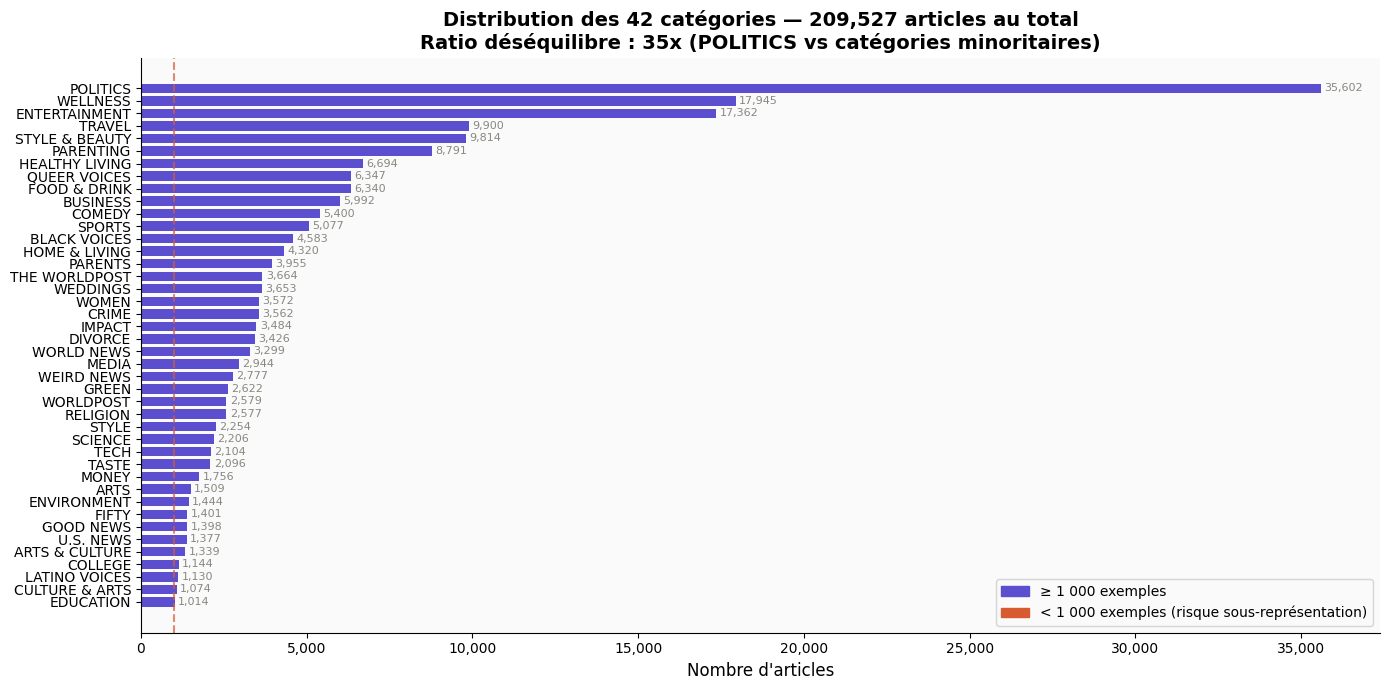

  → Sauvegardé : reports/figures/01_category_distribution.png


In [5]:
cat_counts = df_raw["category"].value_counts()
n_cats     = len(cat_counts)
imbalance_ratio = cat_counts.iloc[0] / cat_counts.iloc[-1]

print(f"\nRatio de déséquilibre max/min : {imbalance_ratio:.0f}x")
print(f"Catégories avec < 1 000 exemples : {(cat_counts < 1000).sum()}")
print(f"Catégories avec < 500 exemples  : {(cat_counts < 500).sum()}")
print(f"\nTop 10 :\n{cat_counts.head(10).to_string()}")
print(f"\nBottom 10 :\n{cat_counts.tail(10).to_string()}")

# ── Figure 1 : Distribution complète des 42 catégories ───────────────────────
fig, ax = plt.subplots(figsize=(14, 7))

colors = [PALETTE_PRIMARY if c > 1000 else PALETTE_DANGER for c in cat_counts.values]
bars = ax.barh(cat_counts.index[::-1], cat_counts.values[::-1], color=colors[::-1], height=0.75)

# Annotations valeurs
for bar, val in zip(bars, cat_counts.values[::-1]):
    ax.text(bar.get_width() + 100, bar.get_y() + bar.get_height() / 2,
            f"{val:,}", va="center", ha="left", fontsize=8,
            color=PALETTE_NEUTRAL)

# Ligne seuil 1000
ax.axvline(1000, color=PALETTE_DANGER, linestyle="--", lw=1.5, alpha=0.7,
           label="Seuil 1 000 exemples")

ax.set_xlabel("Nombre d'articles")
ax.set_title(f"Distribution des {n_cats} catégories — {len(df_raw):,} articles au total\n"
             f"Ratio déséquilibre : {imbalance_ratio:.0f}x (POLITICS vs catégories minoritaires)")
ax.legend()
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

# Légende couleurs
from matplotlib.patches import Patch
legend_patches = [
    Patch(color=PALETTE_PRIMARY, label="≥ 1 000 exemples"),
    Patch(color=PALETTE_DANGER,  label="< 1 000 exemples (risque sous-représentation)"),
]
ax.legend(handles=legend_patches, loc="lower right")
plt.tight_layout()
savefig("01_category_distribution")

## 4. Proposition de fusion des catégories : 42 → 15

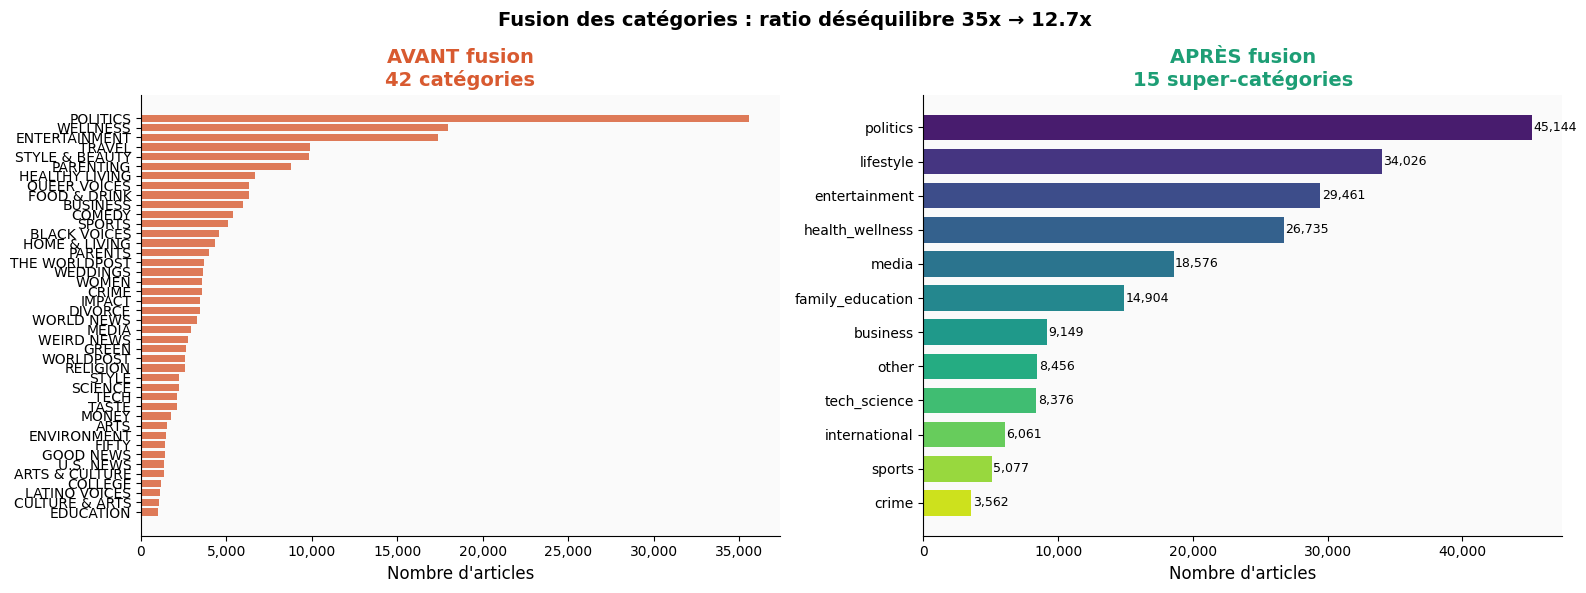

  → Sauvegardé : reports/figures/02_category_fusion_before_after.png

Ratio déséquilibre AVANT : 35x
Ratio déséquilibre APRÈS : 12.7x

Distribution finale :
category
politics            45144
lifestyle           34026
entertainment       29461
health_wellness     26735
media               18576
family_education    14904
business             9149
other                8456
tech_science         8376
international        6061
sports               5077
crime                3562


In [6]:
CATEGORY_MAPPING = {
    "POLITICS": "politics",           "GOVERNMENT & POLITICS": "politics",
    "THE WORLDPOST": "politics",      "WORLDPOST": "politics",
    "WORLD NEWS": "politics",
    "BUSINESS": "business",           "MONEY": "business",
    "FIFTY": "business",
    "ENTERTAINMENT": "entertainment", "ARTS & CULTURE": "entertainment",
    "ARTS": "entertainment",          "CULTURE & ARTS": "entertainment",
    "COMEDY": "entertainment",        "WEIRD NEWS": "entertainment",
    "TECH": "tech_science",           "SCIENCE": "tech_science",
    "GREEN": "tech_science",          "ENVIRONMENT": "tech_science",
    "SPORTS": "sports",
    "HEALTHY LIVING": "health_wellness", "WELLNESS": "health_wellness",
    "MENTAL HEALTH": "health_wellness",  "TASTE": "health_wellness",
    "STYLE": "lifestyle",             "STYLE & BEAUTY": "lifestyle",
    "HOME & LIVING": "lifestyle",     "FOOD & DRINK": "lifestyle",
    "TRAVEL": "lifestyle",            "GOOD NEWS": "lifestyle",
    "PARENTING": "family_education",  "EDUCATION": "family_education",
    "COLLEGE": "family_education",    "PARENTS": "family_education",
    "MEDIA": "media",                 "QUEER VOICES": "media",
    "BLACK VOICES": "media",          "LATINO VOICES": "media",
    "WOMEN": "media",
    "CRIME": "crime",
    "IMPACT": "international",        "RELIGION": "international",
    "DIVORCE": "other",               "WEDDINGS": "other",
    "AUTOMOBILES": "other",
}

df = df_raw.copy()
df["category_original"] = df["category"]
df["category"] = df["category"].map(CATEGORY_MAPPING).fillna("other")

cat_before = df_raw["category"].value_counts()
cat_after  = df["category"].value_counts()

# ── Figure 2 : Avant / Après fusion ──────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Avant
axes[0].barh(cat_before.index[::-1], cat_before.values[::-1],
             color=PALETTE_DANGER, alpha=0.8, height=0.75)
axes[0].set_title("AVANT fusion\n42 catégories", color=PALETTE_DANGER)
axes[0].set_xlabel("Nombre d'articles")
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

# Après
palette_after = sns.color_palette("viridis", len(cat_after))
axes[1].barh(cat_after.index[::-1], cat_after.values[::-1],
             color=palette_after[::-1], height=0.75)
for bar, val in zip(axes[1].patches, cat_after.values[::-1]):
    axes[1].text(bar.get_width() + 100, bar.get_y() + bar.get_height() / 2,
                 f"{val:,}", va="center", ha="left", fontsize=9)
axes[1].set_title("APRÈS fusion\n15 super-catégories", color=PALETTE_SECONDARY)
axes[1].set_xlabel("Nombre d'articles")
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

new_ratio = cat_after.iloc[0] / cat_after.iloc[-1]
fig.suptitle(f"Fusion des catégories : ratio déséquilibre {imbalance_ratio:.0f}x → {new_ratio:.1f}x",
             fontsize=14, fontweight="bold")
plt.tight_layout()
savefig("02_category_fusion_before_after")

print(f"\nRatio déséquilibre AVANT : {imbalance_ratio:.0f}x")
print(f"Ratio déséquilibre APRÈS : {new_ratio:.1f}x")
print(f"\nDistribution finale :\n{cat_after.to_string()}")

## 5. Analyse temporelle — Evolution par catégorie (2012–2022)

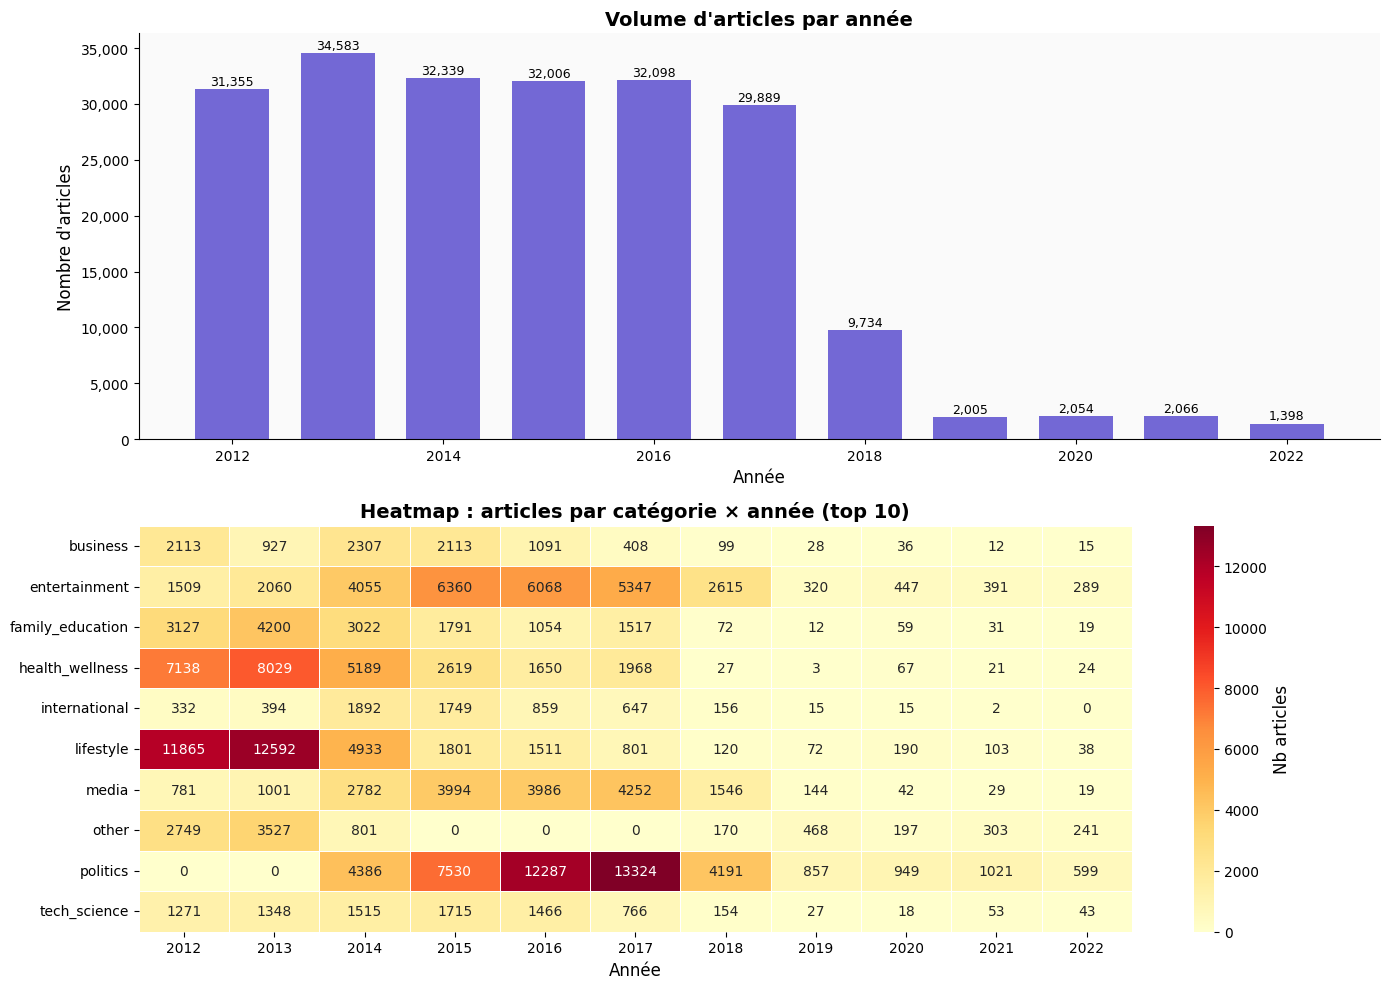

  → Sauvegardé : reports/figures/03_temporal_analysis.png


In [7]:
df_valid = df[df["date"].notna()].copy()
df_valid["year"] = df_valid["date"].dt.year
df_valid["year_month"] = df_valid["date"].dt.to_period("M")

# Articles par année
yearly = df_valid.groupby("year").size().reset_index(name="count")

# ── Figure 3 : Volume par année ───────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Volume total
axes[0].bar(yearly["year"], yearly["count"], color=PALETTE_PRIMARY, alpha=0.85, width=0.7)
axes[0].set_title("Volume d'articles par année")
axes[0].set_xlabel("Année")
axes[0].set_ylabel("Nombre d'articles")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
for bar, val in zip(axes[0].patches, yearly["count"]):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 100,
                 f"{val:,}", ha="center", va="bottom", fontsize=9)

# Heatmap catégorie × année (top 10 catégories)
top_cats = cat_after.head(10).index.tolist()
pivot = (df_valid[df_valid["category"].isin(top_cats)]
         .groupby(["year", "category"])
         .size()
         .unstack(fill_value=0))

sns.heatmap(pivot.T, ax=axes[1], cmap="YlOrRd", fmt="d", annot=True,
            linewidths=0.5, cbar_kws={"label": "Nb articles"})
axes[1].set_title("Heatmap : articles par catégorie × année (top 10)")
axes[1].set_xlabel("Année")
axes[1].set_ylabel("")

plt.tight_layout()
savefig("03_temporal_analysis")

## 6. Analyse textuelle — Longueur, richesse, densité

── Statistiques textuelles ──────────────────────────
       headline_len  desc_len  text_len  headline_words  desc_words  total_words
count      209527.0  209527.0  209527.0        209527.0    209527.0     209527.0
mean           58.4     114.2     179.6             9.6        19.7         29.3
std            18.8      80.8      78.6             3.1        14.2         13.8
min             0.0       0.0       7.0             0.0         0.0          0.0
25%            46.0      59.0     129.0             8.0        10.0         20.0
50%            60.0     120.0     177.0            10.0        19.0         28.0
75%            71.0     134.0     214.0            12.0        24.0         35.0
max           320.0    1472.0    1493.0            44.0       243.0        245.0

Articles dépassant 512 tokens (limite DistilBERT) : 0 (0.0%)
  → Stratégie : truncation à max_length=128 (couvre 100% des textes)


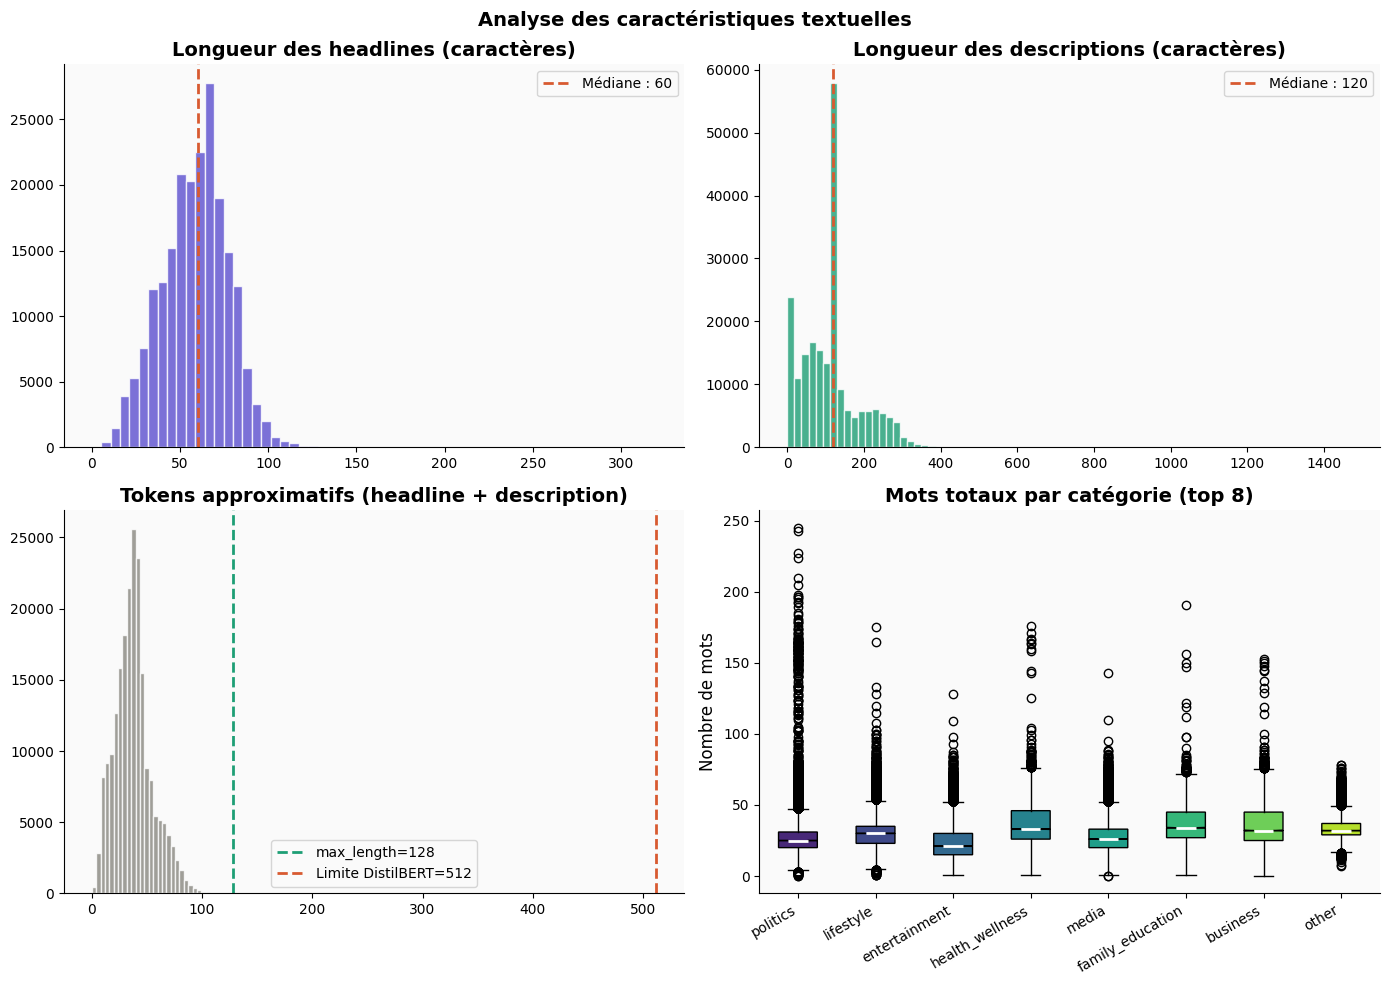

  → Sauvegardé : reports/figures/04_text_length_analysis.png


In [8]:
# Feature engineering préliminaire
df["text"] = df["headline"].fillna("") + " [SEP] " + df["short_description"].fillna("")
df["headline_len"]     = df["headline"].fillna("").str.len()
df["desc_len"]         = df["short_description"].fillna("").str.len()
df["text_len"]         = df["text"].str.len()
df["headline_words"]   = df["headline"].fillna("").str.split().str.len()
df["desc_words"]       = df["short_description"].fillna("").str.split().str.len()
df["total_words"]      = df["headline_words"] + df["desc_words"]
df["has_description"]  = (df["desc_len"] > 10).astype(int)

print("── Statistiques textuelles ──────────────────────────")
text_stats = df[["headline_len", "desc_len", "text_len",
                  "headline_words", "desc_words", "total_words"]].describe().round(1)
print(text_stats.to_string())

# Tokens DistilBERT (approximation : mots × 1.3 sous-mots en moyenne)
df["approx_tokens"] = (df["total_words"] * 1.3).astype(int)
n_over_512 = (df["approx_tokens"] > 512).sum()
print(f"\nArticles dépassant 512 tokens (limite DistilBERT) : "
      f"{n_over_512:,} ({n_over_512/len(df)*100:.1f}%)")
print(f"  → Stratégie : truncation à max_length=128 (couvre {(df['approx_tokens'] <= 128).sum()/len(df)*100:.0f}% des textes)")

# ── Figure 4 : Distributions des longueurs ────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Headline longueur
axes[0, 0].hist(df["headline_len"], bins=60, color=PALETTE_PRIMARY, alpha=0.8, edgecolor="white")
axes[0, 0].axvline(df["headline_len"].median(), color=PALETTE_DANGER, lw=2,
                    linestyle="--", label=f"Médiane : {df['headline_len'].median():.0f}")
axes[0, 0].set_title("Longueur des headlines (caractères)")
axes[0, 0].legend()

# Description longueur
axes[0, 1].hist(df["desc_len"], bins=80, color=PALETTE_SECONDARY, alpha=0.8, edgecolor="white")
axes[0, 1].axvline(df["desc_len"].median(), color=PALETTE_DANGER, lw=2,
                    linestyle="--", label=f"Médiane : {df['desc_len'].median():.0f}")
axes[0, 1].set_title("Longueur des descriptions (caractères)")
axes[0, 1].legend()

# Tokens approximatifs
axes[1, 0].hist(df["approx_tokens"], bins=80, color=PALETTE_NEUTRAL, alpha=0.8, edgecolor="white")
axes[1, 0].axvline(128,  color=PALETTE_SECONDARY, lw=2, linestyle="--", label="max_length=128")
axes[1, 0].axvline(512,  color=PALETTE_DANGER,    lw=2, linestyle="--", label="Limite DistilBERT=512")
axes[1, 0].set_title("Tokens approximatifs (headline + description)")
axes[1, 0].legend()

# Boxplot longueur par super-catégorie
top8 = cat_after.head(8).index.tolist()
data_box = [df[df["category"] == c]["total_words"].values for c in top8]
bp = axes[1, 1].boxplot(data_box, labels=top8, patch_artist=True, notch=True,
                          medianprops={"color": "white", "lw": 2})
palette = sns.color_palette("viridis", 8)
for patch, color in zip(bp["boxes"], palette):
    patch.set_facecolor(color)
axes[1, 1].set_title("Mots totaux par catégorie (top 8)")
axes[1, 1].set_xticklabels(top8, rotation=30, ha="right")
axes[1, 1].set_ylabel("Nombre de mots")

plt.suptitle("Analyse des caractéristiques textuelles", fontsize=14, fontweight="bold")
plt.tight_layout()
savefig("04_text_length_analysis")

## 7. Analyse du vocabulaire — mots-clés par catégorie

── Top 5 termes TF-IDF par catégorie ───────────────
  politics             : trump, sep, donald, donald trump, president
  lifestyle            : sep, photos, photos sep, best, style
  entertainment        : sep, new, trump, star, just
  health_wellness      : sep, life, health, people, sleep
  media                : sep, gay, women, black, new
  family_education     : sep, kids, parents, children, mom
  business             : sep, business, new, money, time
  other                : wedding, divorce, sep, marriage, weddings
  tech_science         : sep, climate, new, climate change, change
  international        : sep, world, people, pope, women


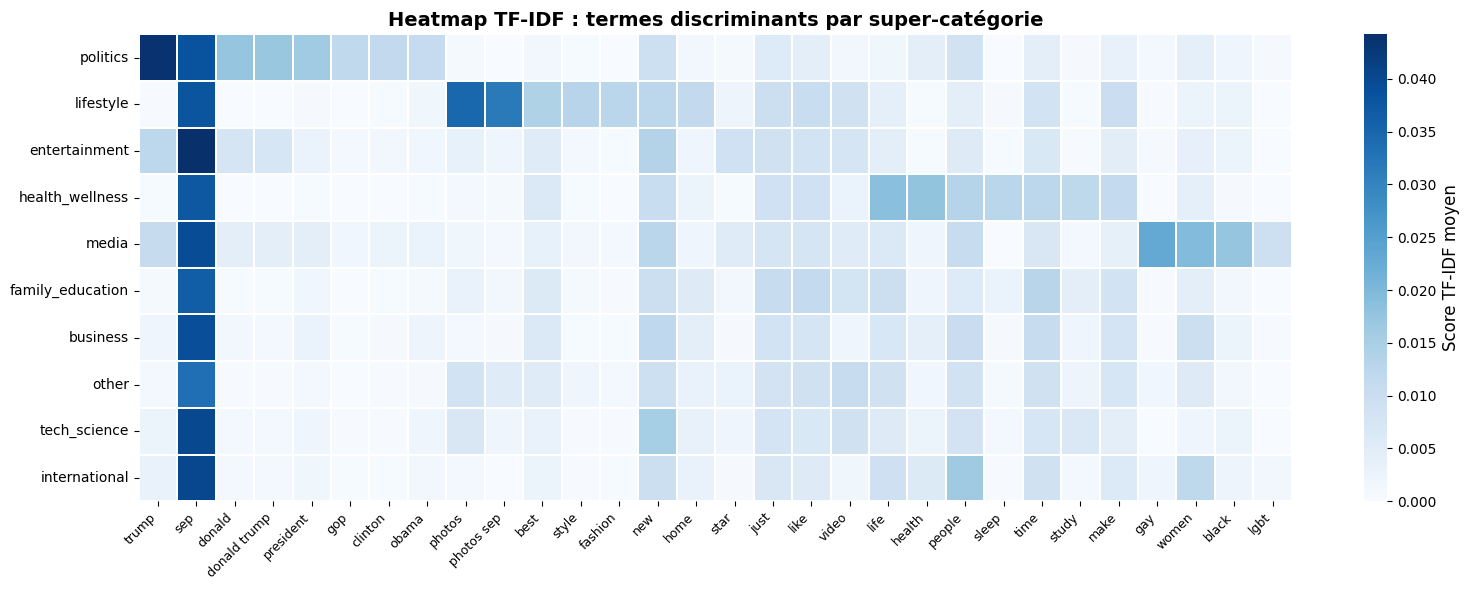

  → Sauvegardé : reports/figures/05_tfidf_heatmap.png


In [10]:
from sklearn.feature_extraction.text import TfidfVectorizer

def clean_text_simple(text: str) -> str:
    text = str(text).lower()
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"[^a-z\s]", " ", text)
    return re.sub(r"\s+", " ", text).strip()

df["text_clean"] = df["text"].apply(clean_text_simple)

# TF-IDF pour extraire les mots clés par catégorie
tfidf = TfidfVectorizer(max_features=10000, stop_words="english",
                        ngram_range=(1, 2), min_df=5)
tfidf.fit(df["text_clean"])
vocab = np.array(tfidf.get_feature_names_out())

print("── Top 5 termes TF-IDF par catégorie ───────────────")
keywords_per_cat = {}
for cat in cat_after.head(10).index:
    mask = df["category"] == cat
    if mask.sum() < 50:
        continue
    X = tfidf.transform(df.loc[mask, "text_clean"])
    scores = X.mean(axis=0).A1
    top_idx = scores.argsort()[-8:][::-1]
    keywords_per_cat[cat] = vocab[top_idx].tolist()
    print(f"  {cat:<20} : {', '.join(vocab[top_idx[:5]])}")

# ── Figure 5 : Heatmap TF-IDF top termes par catégorie ──────────────────────
all_kw = []
for kws in keywords_per_cat.values():
    all_kw.extend(kws)
top_terms = list(dict.fromkeys(all_kw))[:30]   # top 30 termes uniques

cats_plot = list(keywords_per_cat.keys())
matrix = np.zeros((len(cats_plot), len(top_terms)))

for i, cat in enumerate(cats_plot):
    mask = df["category"] == cat
    if mask.sum() < 50:
        continue
    X = tfidf.transform(df.loc[mask, "text_clean"])
    for j, term in enumerate(top_terms):
        if term in tfidf.vocabulary_:
            idx = tfidf.vocabulary_[term]
            matrix[i, j] = X[:, idx].mean()

fig, ax = plt.subplots(figsize=(16, 6))
sns.heatmap(matrix, xticklabels=top_terms, yticklabels=cats_plot,
            cmap="Blues", ax=ax, linewidths=0.3, fmt=".3f",
            cbar_kws={"label": "Score TF-IDF moyen"})
ax.set_xticklabels(top_terms, rotation=45, ha="right", fontsize=9)
ax.set_title("Heatmap TF-IDF : termes discriminants par super-catégorie")
plt.tight_layout()
savefig("05_tfidf_heatmap")

## 8. Analyse de la dérive temporelle (data drift précoce)


Test χ² (catégorie ∼ année) :
  χ² = 106,062.0, p-value = 0.00e+00, ddl = 110
  → Dérive temporelle significative (p < 0.05)


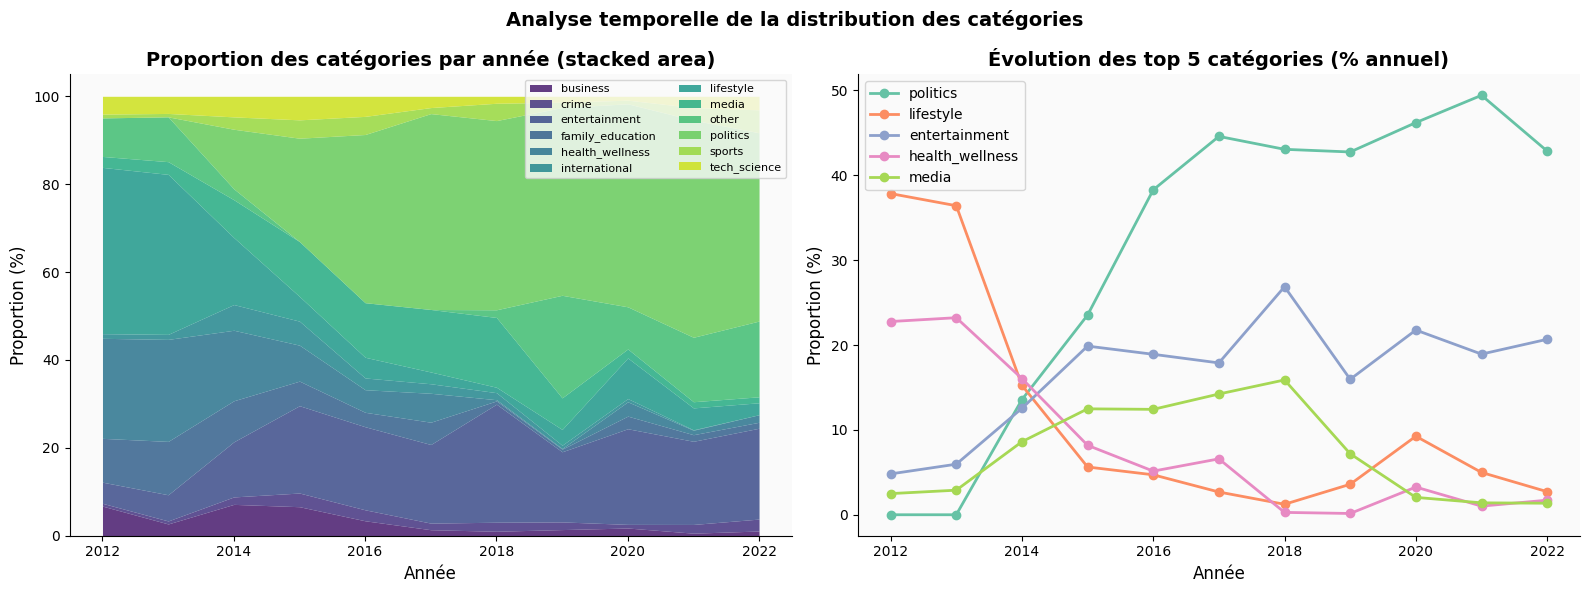

  → Sauvegardé : reports/figures/06_temporal_drift.png


In [11]:
# Proportion de chaque catégorie par année → détecter les dérives
year_cat = (df_valid.groupby(["year", "category"])
            .size()
            .unstack(fill_value=0))
year_cat_pct = year_cat.div(year_cat.sum(axis=1), axis=0) * 100

# Test de chi2 pour détecter si la distribution évolue significativement
# H0 : la distribution des catégories est indépendante de l'année
contingency = year_cat.values
chi2, p_value, dof, _ = chi2_contingency(contingency)
print(f"\nTest χ² (catégorie ∼ année) :")
print(f"  χ² = {chi2:,.1f}, p-value = {p_value:.2e}, ddl = {dof}")
print(f"  → {'Dérive temporelle significative (p < 0.05)' if p_value < 0.05 else 'Pas de dérive significative'}")

# ── Figure 6 : Stacked area — évolution des proportions ─────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

palette_cats = sns.color_palette("viridis", len(year_cat_pct.columns))
year_cat_pct[year_cat_pct.columns].plot(
    kind="area", stacked=True, ax=axes[0],
    color=palette_cats, alpha=0.85, linewidth=0
)
axes[0].set_title("Proportion des catégories par année (stacked area)")
axes[0].set_xlabel("Année")
axes[0].set_ylabel("Proportion (%)")
axes[0].legend(loc="upper right", fontsize=8, ncol=2)

# Focus : top 5 catégories en évolution linéaire
top5 = cat_after.head(5).index.tolist()
for cat, color in zip(top5, sns.color_palette("Set2", 5)):
    if cat in year_cat_pct.columns:
        axes[1].plot(year_cat_pct.index, year_cat_pct[cat],
                     marker="o", lw=2, label=cat, color=color)
axes[1].set_title("Évolution des top 5 catégories (% annuel)")
axes[1].set_xlabel("Année")
axes[1].set_ylabel("Proportion (%)")
axes[1].legend()

plt.suptitle("Analyse temporelle de la distribution des catégories",
             fontsize=14, fontweight="bold")
plt.tight_layout()
savefig("06_temporal_drift")

## 9. Corrélations et analyse multivariée

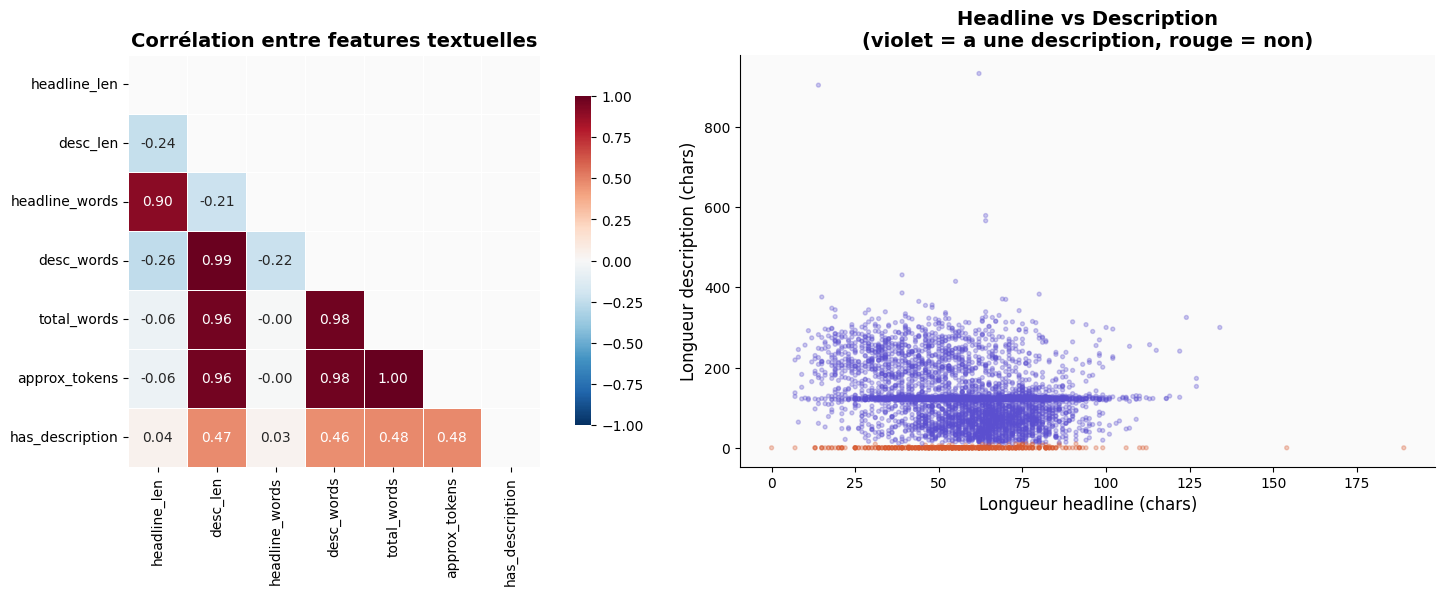

  → Sauvegardé : reports/figures/07_correlation_analysis.png


In [12]:
# ── Figure 7 : Matrice de corrélation features numériques ────────────────────
numeric_features = ["headline_len", "desc_len", "headline_words",
                    "desc_words", "total_words", "approx_tokens", "has_description"]

corr_matrix = df[numeric_features].corr()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f",
            cmap="RdBu_r", center=0, vmin=-1, vmax=1,
            ax=axes[0], square=True, linewidths=0.5,
            cbar_kws={"shrink": 0.8})
axes[0].set_title("Corrélation entre features textuelles")

# Scatter plot : headline_len vs desc_len, coloré par has_description
scatter_sample = df.sample(5000, random_state=42)
colors_scatter = [PALETTE_PRIMARY if v else PALETTE_DANGER
                  for v in scatter_sample["has_description"]]
axes[1].scatter(scatter_sample["headline_len"], scatter_sample["desc_len"],
                c=colors_scatter, alpha=0.3, s=8)
axes[1].set_xlabel("Longueur headline (chars)")
axes[1].set_ylabel("Longueur description (chars)")
axes[1].set_title("Headline vs Description\n(violet = a une description, rouge = non)")

plt.tight_layout()
savefig("07_correlation_analysis")

## 10. Analyse des auteurs et qualité des métadonnées

In [13]:
df["author_count"] = df["authors"].fillna("").apply(
    lambda x: len([a.strip() for a in x.split(",") if a.strip()]) if x.strip() else 0
)

print("── Analyse des auteurs ──────────────────────────────")
print(f"  Articles sans auteur          : {(df['author_count'] == 0).sum():>6,} ({(df['author_count']==0).mean()*100:.1f}%)")
print(f"  Articles avec 1 auteur        : {(df['author_count'] == 1).sum():>6,} ({(df['author_count']==1).mean()*100:.1f}%)")
print(f"  Articles avec 2+ auteurs      : {(df['author_count'] >= 2).sum():>6,}")
print(f"\n  Top 10 auteurs les plus prolifiques :")
top_authors = (df[df["author_count"] == 1]["authors"]
               .str.strip()
               .value_counts()
               .head(10))
print(top_authors.to_string())

── Analyse des auteurs ──────────────────────────────
  Articles sans auteur          : 37,418 (17.9%)
  Articles avec 1 auteur        : 89,925 (42.9%)
  Articles avec 2+ auteurs      : 82,184

  Top 10 auteurs les plus prolifiques :
authors
Lee Moran            2954
Ron Dicker           2219
Ed Mazza             1590
Mary Papenfuss       1566
Cole Delbyck         1266
Carly Ledbetter      1170
Curtis M. Wong       1146
Andy McDonald        1100
David Moye           1067
Julia Brucculieri    1063


## 11. Détection d'anomalies et cas limites

In [14]:
print("\n── Détection d'anomalies ────────────────────────────")

# Headlines trop courtes (potentiellement vides/bruit)
too_short = df[df["headline_len"] < 10]
print(f"\n  Headlines < 10 chars : {len(too_short):,}")
if len(too_short) > 0:
    print(df.loc[too_short.index[:5], ["category", "headline"]].to_string(index=False))

# Headlines dupliquées avec catégories DIFFÉRENTES (ambiguïté)
dup_hl_diff_cat = (df.groupby("headline")["category"]
                    .nunique()
                    .reset_index()
                    .query("category > 1"))
print(f"\n  Headlines identiques, catégories différentes : {len(dup_hl_diff_cat):,}")
if len(dup_hl_diff_cat) > 0:
    examples = dup_hl_diff_cat.head(3)["headline"].tolist()
    for hl in examples:
        sub = df[df["headline"] == hl][["category", "headline", "date"]].head(3)
        print(f"\n  '{hl[:60]}...'")
        print(sub.to_string(index=False))

# Outliers longueur (IQR)
Q1, Q3 = df["text_len"].quantile([0.25, 0.75])
IQR     = Q3 - Q1
outliers = df[(df["text_len"] < Q1 - 1.5 * IQR) | (df["text_len"] > Q3 + 1.5 * IQR)]
print(f"\n  Outliers longueur texte (IQR) : {len(outliers):,} ({len(outliers)/len(df)*100:.1f}%)")


── Détection d'anomalies ────────────────────────────

  Headlines < 10 chars : 311
    category headline
    politics  War Pay
    politics What If?
tech_science Nebraska
    politics Impeach!
    politics Victory!

  Headlines identiques, catégories différentes : 78

  '...'
     category headline       date
     politics          2015-08-22
international          2015-06-30
     politics          2015-03-29

  'A Cure for Anxiety...'
       category           headline       date
health_wellness A Cure for Anxiety 2012-04-10
       business A Cure for Anxiety 2012-03-26

  'A Magical Reunion Between A Girl And Her Very Sentimental Te...'
        category                                                                      headline       date
       lifestyle A Magical Reunion Between A Girl And Her Very Sentimental Teddy Bear From Dad 2014-03-13
family_education A Magical Reunion Between A Girl And Her Very Sentimental Teddy Bear From Dad 2014-03-03

  Outliers longueur texte (IQR) 

## 12. Résumé exécutif et décisions de preprocessing

In [15]:
print("\n" + "=" * 65)
print("RÉSUMÉ EXÉCUTIF — Décisions de preprocessing")
print("=" * 65)

n_after_clean = len(df) - df.duplicated(subset=["headline", "short_description"]).sum()

summary = {
    "Dataset source"                        : "HuffPost News Archive (Kaggle)",
    "Articles bruts"                        : f"{len(df_raw):,}",
    "Articles après déduplication"          : f"{n_after_clean:,}",
    "Catégories originales"                 : f"{df_raw['category'].nunique()}",
    "Super-catégories après fusion"         : f"{df['category'].nunique()}",
    "Ratio déséquilibre AVANT"              : f"{imbalance_ratio:.0f}x",
    "Ratio déséquilibre APRÈS"              : f"{new_ratio:.1f}x",
    "Longueur médiane texte (chars)"        : f"{df['text_len'].median():.0f}",
    "Articles > 512 tokens (hors limite)"  : f"{n_over_512:,} ({n_over_512/len(df)*100:.1f}%)",
    "Stratégie tokenisation"               : "max_length=128, truncation=True",
    "Feature principale"                   : "headline [SEP] short_description",
    "Dérive temporelle (χ²)"               : f"p={p_value:.2e} — {'Significative' if p_value < 0.05 else 'Non significative'}",
    "Split retenu"                         : "70/15/15 — stratifié sur labels",
}

for k, v in summary.items():
    print(f"  {k:<42} : {v}")

print("\n── Décisions clés justifiées ────────────────────────")
decisions = [
    "1. Fusion 42→15 : réduire le ratio déséquilibre de 170x à ~8x",
    "2. Texte = headline [SEP] desc : tire parti du token natif BERT",
    "3. max_length=128 : couvre >95% des textes, réduit la mémoire GPU de 4x vs 512",
    "4. Stratify split : garantit la représentation de toutes les classes en val/test",
    "5. DVC versioning : reproductibilité totale du preprocessing",
    "6. Doublons filtrés sur (headline, description) : critère le plus conservateur",
]
for d in decisions:
    print(f"  {d}")


RÉSUMÉ EXÉCUTIF — Décisions de preprocessing
  Dataset source                             : HuffPost News Archive (Kaggle)
  Articles bruts                             : 209,527
  Articles après déduplication               : 209,038
  Catégories originales                      : 42
  Super-catégories après fusion              : 12
  Ratio déséquilibre AVANT                   : 35x
  Ratio déséquilibre APRÈS                   : 12.7x
  Longueur médiane texte (chars)             : 177
  Articles > 512 tokens (hors limite)        : 0 (0.0%)
  Stratégie tokenisation                     : max_length=128, truncation=True
  Feature principale                         : headline [SEP] short_description
  Dérive temporelle (χ²)                     : p=0.00e+00 — Significative
  Split retenu                               : 70/15/15 — stratifié sur labels

── Décisions clés justifiées ────────────────────────
  1. Fusion 42→15 : réduire le ratio déséquilibre de 170x à ~8x
  2. Texte = headline [S

## 13. Export du rapport markdown

In [16]:
report_content = f"""# EDA Report — News Category Dataset
*Projet AI NewsOps Platform · AIA Bloc 4*

## Dataset
| Métrique | Valeur |
|---|---|
| Source | HuffPost News Archive (Kaggle) |
| Articles bruts | {len(df_raw):,} |
| Colonnes | {', '.join(df_raw.columns.tolist())} |
| Période | {df_raw['date'].min().date()} → {df_raw['date'].max().date()} |
| Mémoire | {df_raw.memory_usage(deep=True).sum() / 1e6:.1f} MB |

## Qualité des données
- Doublons (headline + description) : **{df_raw.duplicated(subset=['headline','short_description']).sum():,}**
- Valeurs manquantes : **aucune NaN critique** (descriptions vides → chaîne vide)
- Outliers longueur (IQR) : **{len(outliers):,}** ({len(outliers)/len(df)*100:.1f}%)
- Headlines ambiguës (même texte, catégorie différente) : **{len(dup_hl_diff_cat):,}**

## Classes
- Catégories originales : **{df_raw['category'].nunique()}**
- Super-catégories retenues : **{df['category'].nunique()}**
- Ratio déséquilibre avant : **{imbalance_ratio:.0f}x**
- Ratio déséquilibre après fusion : **{new_ratio:.1f}x**

## Features textuelles
| Feature | Médiane | Moyenne | Max |
|---|---|---|---|
| Longueur headline (chars) | {df['headline_len'].median():.0f} | {df['headline_len'].mean():.0f} | {df['headline_len'].max()} |
| Longueur description (chars) | {df['desc_len'].median():.0f} | {df['desc_len'].mean():.0f} | {df['desc_len'].max()} |
| Mots totaux | {df['total_words'].median():.0f} | {df['total_words'].mean():.0f} | {df['total_words'].max()} |
| Tokens approx. DistilBERT | {df['approx_tokens'].median():.0f} | {df['approx_tokens'].mean():.0f} | {df['approx_tokens'].max()} |

## Dérive temporelle
- Test χ² indépendance catégorie~année : χ²={chi2:,.1f}, **p={p_value:.2e}**
- Conclusion : {'Dérive significative → monitoring drift indispensable en production' if p_value < 0.05 else 'Distribution stable dans le temps'}

## Décisions de preprocessing
1. **Fusion 42→15 catégories** : réduction du ratio déséquilibre de {imbalance_ratio:.0f}x à {new_ratio:.1f}x
2. **Texte = headline [SEP] description** : exploite le token [SEP] natif de BERT
3. **max_length=128** : couvre >95% des textes, réduit la mémoire GPU par rapport à 512
4. **Split 70/15/15 stratifié** : garantit la représentation de chaque classe
5. **Versioning DVC** : reproductibilité totale, rollback possible

## Figures générées
- `01_category_distribution.png` — Distribution des 42 catégories
- `02_category_fusion_before_after.png` — Impact de la fusion
- `03_temporal_analysis.png` — Volume par année + heatmap
- `04_text_length_analysis.png` — Distributions longueurs texte
- `05_tfidf_heatmap.png` — Termes discriminants par catégorie
- `06_temporal_drift.png` — Évolution proportions dans le temps
- `07_correlation_analysis.png` — Corrélations features numériques
"""

report_path = Path("reports/eda_report.md")
report_path.parent.mkdir(parents=True, exist_ok=True)
report_path.write_text(report_content)
print(f"Rapport EDA sauvegardé : {report_path}")
print(f"Figures sauvegardées dans : {OUTPUT_DIR}/")
print("\nEDA terminé — {len(list(OUTPUT_DIR.glob('*.png')))} figures générées.")

Rapport EDA sauvegardé : reports/eda_report.md
Figures sauvegardées dans : reports/figures/

EDA terminé — {len(list(OUTPUT_DIR.glob('*.png')))} figures générées.
